In [1]:
#!/usr/bin/env python
# -*- encoding: utf-8
import os
import sys
import numpy as np
import itertools as itools
from dask.distributed import Client, LocalCluster
from dask.distributed import get_client
import xarray as xr
import core_scripts
from core_scripts import *

In [2]:
models = ["NorESM2-LM"]#["IPSL-CM6A-LR"]#["NorESM2-MM"]#
no_members = 6

members = [f"r{r}i1p1f1" for r in range(1, no_members+1)]
# members = ["r1i1p1f1", "r2i1p1f1", "r3i1p1f1"]
future_experiment = "ssp370"
experiments = ["historical", future_experiment]	
# combinations = [
#     f"--{model} --{member} --{experiment}"
#     for model, member, experiment
#         in itools.product(models, members, experiments)]
combinations = [
    dict(zip(["model", "experiment", "member"],[model, experiment, member]))
    for model, experiment, member
        in itools.product(models, experiments, members)]
combinations

[{'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r1i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r2i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r3i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r4i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r5i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'historical', 'member': 'r6i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r1i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r2i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r3i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r4i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r5i1p1f1'},
 {'model': 'NorESM2-LM', 'experiment': 'ssp370', 'member': 'r6i1p1f1'}]

In [3]:
model, experiment, member = combinations[3].values()
model, experiment, member

('NorESM2-LM', 'historical', 'r4i1p1f1')

In [4]:
auxdir = "/home/jlu044/CMIP-EU-precip-precursors/aux"
args = decompose_precip.run_decompose_precip(
    model, future_experiment, historical_members=members, future_members=members[:3],
    auxdir=auxdir, overwrite=True)

args

Namespace(model='NorESM2-LM', future_experiment='ssp370', eventthreshold=0.95, nprecursorbins=10, seasons=['DJF', 'MAM', 'JJA', 'SON'], regions=None, historical_members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1'], future_members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], referencemodel='ERA5', historical_experiment='historical', hist_period=[1979, 2014], future_period=[2060, 2100], variables=['z500', 'u850', 'v850'], hazardvariable='pr', overwrite=True, inputdir='/Data/skd/projects/global/cmip6_precursors/outputs/indices/', auxdir='/home/jlu044/CMIP-EU-precip-precursors/aux', savedir='/Data/skd/projects/global/cmip6_precursors/outputs/decompositions/')

In [5]:
decompose_precip.get_savepaths(args, "DJF", 14)

('/Data/skd/projects/global/cmip6_precursors/outputs/decompositions//NorESM2-LM/historical_r1i1p1f1_through_r6i1p1f1_ssp370_r1i1p1f1_r2i1p1f1_r3i1p1f1/decomp_DJF_region14.csv',
 '/Data/skd/projects/global/cmip6_precursors/outputs/decompositions//NorESM2-LM/historical_r1i1p1f1_through_r6i1p1f1_ssp370_r1i1p1f1_r2i1p1f1_r3i1p1f1/terms_DJF_region14.csv')

In [ ]:
# sys.path.append(args.auxdir)
# print(args.auxdir)
# from decomposition import decompose_hazard_odds_ratio,decomp_to_pd_df,decomp_to_term_pd_df
# condition_var=args.variables
# if len(condition_var)==1:
#     condition_var=condition_var[0]
# else:
#     #This principal component is fitted in the reference dataset and projected
#     #on the models.
#     condition_var='PC1'

# p_dvs=[v+'_lag0_index_val1' for v in args.variables]
# #use a pre-established set of regions if none specified
# if args.regions is None:
#     # region 2 was an uninhabited island so we dropped it.
#     args.regions=[1,*np.arange(3,40)] 
# else:
#     pass
# ref_data=decompose_precip.get_ref_data(args)
# hist_data=decompose_precip.get_hist_data(args)
# future_data=decompose_precip.get_future_data(args)
# hazard_var=args.hazardvariable
# make_h_var_cat=True
# p=args.eventthreshold
# bin_num=args.nprecursorbins
# model=args.model

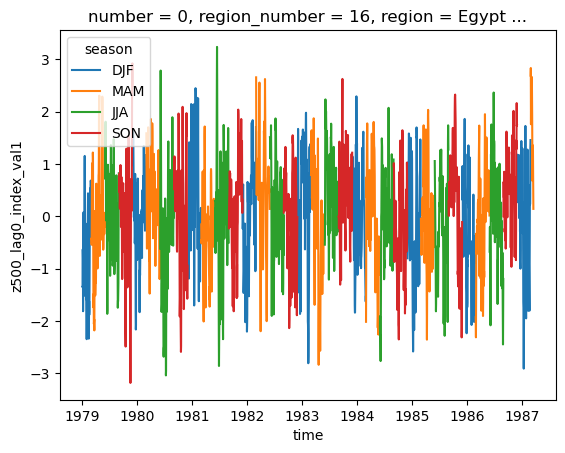

In [19]:
ref_data.z500_lag0_index_val1.isel(time=slice(0,3000), region_id=14).plot(hue="season")

In [66]:
args = decompose_precip.run_decompose_precip(model, experiment, members=member)
if args.regions is None:
    # region 2 was an uninhabited island so we dropped it.
    args.regions=[1,*np.arange(3,40)]

future_data=decompose_precip.get_future_data(args)

In [32]:
%load_ext autoreload
%autoreload 2


In [76]:
from decomposition import  *


In [83]:
fd

<xarray.Dataset> Size: 958kB
Dimensions:               (time: 14965)
Coordinates: (12/14)
  * time                  (time) object 120kB 2060-01-01 12:00:00 ... 2100-12...
    lag                   int32 4B 0
    region                object 8B 'Turkey'
    number                int64 8B 0
    region_number         int32 4B 1
    quantile              float64 8B 0.95
    ...                    ...
    index_val             int64 8B 1
    plev                  float64 8B 5e+04
    year                  (time) float64 120kB 2.06e+03 2.06e+03 ... 2.1e+03
    month                 (time) float64 120kB 1.0 1.0 1.0 ... 12.0 12.0 12.0
    dayofyear             (time) float64 120kB 1.0 2.0 3.0 ... 363.0 364.0 365.0
    tp                    float64 8B 1.0
Data variables:
    z500_lag0_index_val1  (time) float64 120kB -57.96 -57.88 ... -57.89 -57.24
    u850_lag0_index_val1  (time) float64 120kB -0.4797 0.02515 ... 0.4427 0.699
    v850_lag0_index_val1  (time) float64 120kB -0.6166 0.4499 ... -0.4099 0.8861
    pr                    (time) float64 120kB 0.001636 3.225 ... 1.132 3.496
Attributes: (12/14)
    model:        NorESM2-LM
    experiment:   ssp370
    member:       r1i1p1f1
    variables:    z500_detrend,u850,v850
    overwrite:    True
    seasons:      DJF,MAM,JJA,SON
    ...           ...
    inputdir:     /Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/
    auxdir:       /Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/
    savedir:      /Data/skd/projects/global/cmip6_precursors/outputs/indices/
    precursorid:  standard
    refid:        ERA5
    debug:        True

In [64]:
args.regions

In [85]:
condition_var

'PC1'

In [20]:
for s in args.seasons[:]:
    for r in args.regions[:]:
        try:
            decomp_path,term_path=decompose_precip.get_savepaths(args,s,r)
            rd=ref_data.sel(season=s,region_id=r).rename(tp='pr')
            hd=hist_data.sel(season=s,region_id=r)
            if future_data is None:
                fd=hd
            else:
                fd=future_data.sel(season=s,region_id=r)
            hd = xr.concat([hd.sel(member=k, drop=True) for k in hd.member], dim='time')
            fd = xr.concat([fd.sel(member=k, drop=True) for k in fd.member], dim='time')
            decomposed_hazard=decompose_hazard_odds_ratio(rd.dropna('time'),
                                                          hd.dropna('time'),
                                                          fd.dropna('time'),                                             
                                                        hazard_var,condition_var,
                                                        make_h_var_cat=make_h_var_cat,
                                                        p_dvs=p_dvs,
                                                        quantile=p,bin_num=bin_num)
            #format the decomposed quantities
            decomposed_df=decomp_to_pd_df(decomposed_hazard,model,s,r)
            #compute and format decomposition terms.
            #We don't currently save this.
            terms_df=decomp_to_term_pd_df(decomposed_hazard,model,s,r)
            
            #sum the terms over all bins, which we do save:
            summed_terms_df=terms_df.groupby(
                ["model","season","region_id", "source", "term"], 
                as_index=False
            )["value"].sum()
            
            os.makedirs('/'.join(decomp_path.split('/')[:-1]), exist_ok=True)
            os.makedirs('/'.join(term_path.split('/')[:-1]), exist_ok=True)
            #subprocess.run(["chmod", "-R", "g+rwx", ('/'.join(decomp_path.split('/')[:-1]))], check=True)
            #subprocess.run(["chmod", "-R", "g+rwx", '/'.join(term_path.split('/')[:-1])], check=True)
            decomposed_df.to_csv(decomp_path)
            summed_terms_df.to_csv(term_path)
        except Exception as e:
            print(s,r, e)

JJA 25 Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by PCA.


In [91]:
import pandas as pd

In [93]:
import subprocess

In [5]:
xr.open_dataarray?

Signature:
xr.open_dataarray(
    filename_or_obj: 'str | os.PathLike[Any] | BufferedIOBase | AbstractDataStore',
    *,
    engine: 'T_Engine | None' = None,
    chunks: 'T_Chunks | None' = None,
    cache: 'bool | None' = None,
    decode_cf: 'bool | None' = None,
    mask_and_scale: 'bool | None' = None,
    decode_times: 'bool | None' = None,
    decode_timedelta: 'bool | None' = None,
    use_cftime: 'bool | None' = None,
    concat_characters: 'bool | None' = None,
    decode_coords: "Literal['coordinates', 'all'] | bool | None" = None,
    drop_variables: 'str | Iterable[str] | None' = None,
    inline_array: 'bool' = False,
    chunked_array_type: 'str | None' = None,
    from_array_kwargs: 'dict[str, Any] | None' = None,
    backend_kwargs: 'dict[str, Any] | None' = None,
    **kwargs,
) -> 'DataArray'
Docstring:
Open an DataArray from a file or file-like object containing a single
data variable.

This is designed to read netCDF files with only one data variable. If
multiple v

In [88]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA

def decompose_hazard_odds_ratio(ref_ds,h_model_ds,
                                f_model_ds,h_var,s_var,bin_num=5,
                                p_dvs=None,make_h_var_cat=False,quantile=None):
    return _prep_and_decompose(binned_decomposition,return_decomp_as_dataarray,
                               ref_ds,h_model_ds,f_model_ds,h_var,s_var,bin_num,p_dvs,make_h_var_cat,quantile)

def _prep_and_decompose(decomp_func,output_func,ref_ds,
                        h_model_ds,f_model_ds,h_var,s_var,bin_num,p_dvs,make_h_var_cat,quantile):

    #needed if returned with full_output, but not used.
    ref_PCA_Solver=None
    quantile_thresh=None
    PCs=None
    EOFs=None
    #handle PCA projection (based on ref_ds variability) if needed.
    if s_var[:2]=='PC':

        if p_dvs is None:
            print('Using default p_dvs: Z500, U850 and V850')
            p_dvs=['z500_lag0_index_val1',
                   'u850_lag0_index_val1',
                   'v850_lag0_index_val1']

        pcN=int(s_var[2:])
        ref_ds,ref_PCA_Solver,PCs,EOFs=fit_PCA_to_ds(ref_ds,pcN,p_dvs)
        h_model_ds[s_var]=xr.DataArray(data=apply_PCA_to_ds(h_model_ds,ref_PCA_Solver,pcN,p_dvs),
                                      coords=dict(time=h_model_ds.time)
                                      )
        f_model_ds[s_var]=xr.DataArray(data=apply_PCA_to_ds(f_model_ds,ref_PCA_Solver,pcN,p_dvs),
                                      coords=dict(time=f_model_ds.time)
                                      )
    #handle categorical event def if needed.
    if make_h_var_cat:
        if quantile is None:
            raise(ValueError('Need quantile for exceedance calculation if make_h_var_cat is True'))
        
        quantile_thresh=ref_ds[h_var].quantile(quantile)

        ref_ds[h_var+'_cat']=(ref_ds[h_var]>quantile_thresh).astype(int)
        h_model_ds[h_var+'_cat']=(h_model_ds[h_var]>quantile_thresh).astype(int)
        f_model_ds[h_var+'_cat']=(f_model_ds[h_var]>quantile_thresh).astype(int)

        h_var=h_var+'_cat'
    
    #make sure we have binary event time series, or else I expect the computation will be wrong. If we change our mind we can delete this block.
    
    unique_h_vals=[np.unique(ds[h_var]) for ds in [ref_ds,h_model_ds,f_model_ds]]
    try:
        assert np.all([unique_vals==[0,1] for unique_vals in unique_h_vals])
    except:
        raise(ValueError(f'Expected binary event values, got: {unique_h_vals}'))

    #our bins are based on the reference ds. We've modified this to include two unobserved bins, at the high and low end. 
    bins=np.array([-1000,*ref_ds[s_var].quantile(np.linspace(0,1,bin_num+1)),1000])
    bins[1]=bins[1]-0.01 # so min ref value is not included in unobserved first bin
    bin_centres=(bins[1:]+bins[:-1])/2

    Ph_s_0, P_s_0 = decomp_func(ref_ds,h_var,s_var,bins)

    assert (Ph_s_0[0]==0)&(Ph_s_0[-1]==0)
############
    attrs_h_model_ds = h_model_ds[s_var].attrs
    h_model_ds[s_var].attrs = {}
    attrs_f_model_ds = f_model_ds[s_var].attrs
    f_model_ds[s_var].attrs = {}

    Ph_s_h, P_s_h = decomp_func(h_model_ds,h_var,s_var,bins)
    Ph_s_f, P_s_f = decomp_func(f_model_ds,h_var,s_var,bins)

    h_model_ds[s_var].attrs = attrs_h_model_ds
    f_model_ds[s_var].attrs = attrs_f_model_ds

    return output_func([Ph_s_0,Ph_s_h,Ph_s_f,P_s_0,P_s_h,P_s_f])

def return_decomp_as_dataarray(data):
    dims=('statistic','synoptic_bin')

    coords=dict(synoptic_bin=np.arange(len(data[0])),
                statistic=['therm_ref','therm_hist','therm_future',
                    'dyn_ref','dyn_hist','dyn_future']
                )
    return xr.DataArray(data=data,dims=dims,coords=coords)


def binned_decomposition(ds,h_var,s_var,bins):
    """helper func for decompose_hazard_odds_ratio"""
    # print(ds)
    # print(ds[s_var])
    Ph_s=ds.groupby_bins(s_var,bins=bins).mean()[h_var].fillna(0) #average value of hazard in bin. Is a probability for binary data. Bins with no hazard risk get a 0
    P_s=ds.groupby_bins(s_var,bins=bins).count()[s_var].fillna(0)/ds[s_var].time.size #occurence prob of synoptic bin. Bins that don't occur get a 0.

    return Ph_s, P_s

def fit_PCA_to_ds(ds,N,p_dvs):
    """helper func for decompose_hazard_odds_ratio"""

    X=ds[p_dvs].to_array('feature').T

    Solver=PCA(n_components=N,whiten=True).fit(X)
    principal_components=Solver.transform(X)
    
    #assuming ds has a dim 'time'
    PCs=xr.DataArray(data=principal_components,
        coords=dict(time=X.time.values,component=range(1,N+1)),dims=('time','component'))

    EOFs=xr.DataArray(data=Solver.components_,
        coords=dict(precursor=X.feature.values,component=range(1,N+1)),dims=('component','precursor'))
    EOFs=EOFs.assign_coords(explained_var=('component',Solver.explained_variance_ratio_))

    #add PC to ds
    ds['PC'+str(N)]=PCs.sel(component=N)
    return ds, Solver, PCs, EOFs

def apply_PCA_to_ds(ds,Solver,N,p_dvs):

    X=ds[p_dvs].to_array('feature').T

    return Solver.transform(X)[:,N-1]

def compute_terms_from_decomposition(Ph_s_0,Ph_s_h,Ph_s_f,P_s_0,P_s_h,P_s_f):

    N=len(Ph_s_0)
    #we make modifications for the unobserved_low and unobserved_hi bins (novel dynamics):
    for ix in [0,-1]:
        try:
            assert P_s_0[ix]==0
        except:
            raise(ValueError(f'The ref occurrence of bin {ix} should be 0 by design; instead {P_s_0[ix]}'))
        
        #if this bin occurred in the historical simulation, we treat its hazard risk as the 
        #true value for obs, as per our analytical analysis.
        #xi will then be 0, and the non-zero terms in odds_numerator can be interpreted directly.
        if P_s_h[ix]!=0:
            Ph_s_0[ix]=Ph_s_h[ix]

        #If it only occurs in the future sim, then we have no way of decomposing the contribution. 
        #We simply want to keep a trend contribution Ph_s_f*P_s_f.
        #Therefore we want Delta_P_s to be P_s_f, already satisfied as P_s_h=0. 
        # We set Ph_s_0[ix] to be Ph_s_f[ix]. Alpha, xi, and delta will be zero, so only dyn trend will remain, as desired.
        #if the future bin is also zero then this all works out the same.
        else:
            Ph_s_0[ix]=Ph_s_f[ix]

    #to handle bins that go from zero to nonzero hazard risk, we use a numerical trick, adding epsilons to Ph_s_0 and Ph_s_h.
    #The resulting error is at most epsilon*P_s, so bounded at 1*epsilon.
    epsilon=1e-12  
    Ph_s_0=Ph_s_0+epsilon
    Ph_s_h=Ph_s_h+epsilon

    #The most basic terms: ratios and anomalies of conditional and thermodynamic rainfall.

    #xi = therm_bias
    #alpha = therm_trend
    xi    = (Ph_s_h/Ph_s_0) -1
    alpha = (Ph_s_f/Ph_s_h) -1

    #when Ph_s_h is near 0 but Ph_s_0 isn't, alpha can't be sensibly estimated.
    # In this case we treat it as an additive contribution and set
    # alpha = Ph_s_f/Ph_s_0 so final therm trend will be P_s_0*Ph_s_f
    special_case= (Ph_s_h<1e-10)&(Ph_s_0>=1e-10)
    alpha[special_case]=Ph_s_f[special_case]/Ph_s_0[special_case]

    #little delta = dyn bias
    #Big Delta = dyn trend
    delta_P_s=P_s_h-P_s_0
    Delta_P_s=P_s_f-P_s_h

    # Estimates of bias, and the true trend based on these lowest coefficients

    #bias terms
    therm_bias=xi*Ph_s_0*P_s_0
    dyn_bias=delta_P_s*Ph_s_0
    nl_bias=xi*delta_P_s*Ph_s_0
    #trend terms
    therm_trend=alpha*P_s_0*Ph_s_0
    dyn_trend=Delta_P_s*Ph_s_0
    nl_trend=alpha*Delta_P_s*Ph_s_0

    #Relevance is a source-agnostic calculation of the contribution of each bin
    #to event probability
    ref_relevance=(Ph_s_0*P_s_0)
    hst_relevance=(Ph_s_h*P_s_h)
    fut_relevance=(Ph_s_f*P_s_f)

    #The bias free estimate of the future hazard.
    PH_f=(Ph_s_0*(P_s_0+ alpha*P_s_0 + Delta_P_s*(1+alpha))).sum()

    #true trend represented as a multiple of the model frequency
    beta=PH_f/ref_relevance.sum().values -1

    #direct naive estimate of trend
    beta_tilde=(fut_relevance.sum()/hst_relevance.sum().values) -1

    gamma=Delta_P_s/(P_s_0+epsilon)
    omega=delta_P_s/(P_s_h+epsilon)
    F_tilde=hst_relevance/hst_relevance.sum()
    F=ref_relevance/ref_relevance.sum()
    F_star=fut_relevance/fut_relevance.sum()

    therm_trend_error=alpha*(F_tilde-F)
    dyn_trend_error=gamma*(F_tilde*omega -F)
    nl_trend_error=gamma*alpha*(F_tilde*omega -F)

    #for returning data, we mask out alpha for the special case:
    alpha[special_case]=np.nan

    coefficient_da=xr.DataArray(data=[[xi,alpha],[delta_P_s,Delta_P_s]],
                 coords=dict(source=['therm','dyn'],term=['bias','trend'],synoptic_bin=np.arange(0,N)),
                 dims=('source','term','synoptic_bin'),name='coefficient')
    
    individual_term_da=xr.DataArray(data=[[therm_bias,therm_trend,therm_trend_error],
                                          [dyn_bias,dyn_trend,dyn_trend_error],
                                          [nl_bias,nl_trend,nl_trend_error]],
                 coords=dict(source=['therm','dyn','nonlinear'],term=['bias','trend','spurious_trend'],synoptic_bin=np.arange(0,N)),
                 dims=('source','term','synoptic_bin'),name='individual_term')
    
    beta_da=xr.DataArray(data=[beta,beta_tilde],coords=dict(term=['trend','spurious_trend']),dims=('term'),name='multiplicative_trend')

    contribution_da=xr.DataArray(data=[F,F_tilde,F_star],coords=dict(term=['ref','bias','trend'],synoptic_bin=np.arange(0,N)),
                                 dims=('term','synoptic_bin'),name='contribution')
    

    ds=xr.merge([coefficient_da,individual_term_da,beta_da,contribution_da])
    return ds

def blending_function(Ph_s_h,Ph_s_0,pow,mu):
    x=Ph_s_h/Ph_s_0
    return x**pow/(x**pow+mu**pow)


def compute_terms_from_decomposition_with_alpha_blending(Ph_s_0,Ph_s_h,Ph_s_f,P_s_0,P_s_h,P_s_f,blending_pow=4,blending_param=0.1):

    N=len(Ph_s_0)
    #we make modifications for the unobserved_low and unobserved_hi bins (novel dynamics):
    for ix in [0,-1]:
        try:
            assert P_s_0[ix]==0
        except:
            raise(ValueError(f'The ref occurrence of bin {ix} should be 0 by design; instead {P_s_0[ix]}'))
        
        #if this bin occurred in the historical simulation, we treat its hazard risk as the 
        #true value for obs, as per our analytical analysis.
        #xi will then be 0, and the non-zero terms in odds_numerator can be interpreted directly.
        if P_s_h[ix]!=0:
            Ph_s_0[ix]=Ph_s_h[ix]

        #If it only occurs in the future sim, then we have no way of decomposing the contribution. 
        #We simply want to keep a trend contribution Ph_s_f*P_s_f.
        #Therefore we want Delta_P_s to be P_s_f, already satisfied as P_s_h=0. 
        # We set Ph_s_0[ix] to be Ph_s_f[ix]. Alpha, xi, and delta will be zero, so only dyn trend will remain, as desired.
        #if the future bin is also zero then this all works out the same.
        else:
            Ph_s_0[ix]=Ph_s_f[ix]

    #to handle bins that go from zero to nonzero hazard risk, we use a numerical trick, adding epsilons to Ph_s_0 and Ph_s_h.
    #The resulting error is at most epsilon*P_s, so bounded at 1*epsilon.
    epsilon=1e-12  
    Ph_s_0=Ph_s_0+epsilon
    Ph_s_h=Ph_s_h+epsilon

    #The most basic terms: ratios and anomalies of conditional and thermodynamic rainfall.

    #xi = therm_bias
    #alpha = therm_trend
    xi    = (Ph_s_h/Ph_s_0) -1

    #alpha is generally multiplicative, but for very small Ph_s_h, this creates insane trends.
    #We add a smooth blending to an additive therm component for these cases.
    w=blending_function(Ph_s_h,Ph_s_0,blending_pow,blending_param)
    alpha=(1-w)*Ph_s_f/Ph_s_0 + w*((Ph_s_f/Ph_s_h) -1)

    #little delta = dyn bias
    #Big Delta = dyn trend
    delta_P_s=P_s_h-P_s_0
    Delta_P_s=P_s_f-P_s_h

    # Estimates of bias, and the true trend based on these lowest coefficients

    #bias terms
    therm_bias=xi*Ph_s_0*P_s_0
    dyn_bias=delta_P_s*Ph_s_0
    nl_bias=xi*delta_P_s*Ph_s_0
    #trend terms
    therm_trend=alpha*P_s_0*Ph_s_0
    dyn_trend=Delta_P_s*Ph_s_0
    nl_trend=alpha*Delta_P_s*Ph_s_0

    #Relevance is a source-agnostic calculation of the contribution of each bin
    #to event probability
    ref_relevance=(Ph_s_0*P_s_0)
    hst_relevance=(Ph_s_h*P_s_h)
    fut_relevance=(Ph_s_f*P_s_f)

    #The bias free estimate of the future hazard.
    PH_f=(Ph_s_0*(P_s_0+ alpha*P_s_0 + Delta_P_s*(1+alpha))).sum()

    #true trend represented as a multiple of the model frequency
    beta=PH_f/ref_relevance.sum().values -1

    #direct naive estimate of trend
    beta_tilde=(fut_relevance.sum()/hst_relevance.sum().values) -1

    #gamma isn't defined for our top and bottom unseen bins,
    # so we want it additively in these cases:
    w=blending_function(Delta_P_s,P_s_0,4,1e3)
    gamma=w*Delta_P_s/(P_s_0+epsilon) + (1-w)*Delta_P_s/(P_s_h+epsilon)

    omega=delta_P_s/(P_s_h+epsilon)
    F_tilde=hst_relevance/hst_relevance.sum()
    F=ref_relevance/ref_relevance.sum()
    F_star=fut_relevance/fut_relevance.sum()

    therm_trend_error=alpha*(F_tilde-F)
    dyn_trend_error=gamma*(F_tilde*omega -F)
    nl_trend_error=gamma*alpha*(F_tilde*omega -F)

    coefficient_da=xr.DataArray(data=[[xi,alpha],[delta_P_s,Delta_P_s]],
                 coords=dict(source=['therm','dyn'],term=['bias','trend'],synoptic_bin=np.arange(0,N)),
                 dims=('source','term','synoptic_bin'),name='coefficient')
    
    individual_term_da=xr.DataArray(data=[[therm_bias,therm_trend,therm_trend_error],
                                          [dyn_bias,dyn_trend,dyn_trend_error],
                                          [nl_bias,nl_trend,nl_trend_error]],
                 coords=dict(source=['therm','dyn','nonlinear'],term=['bias','trend','spurious_trend'],synoptic_bin=np.arange(0,N)),
                 dims=('source','term','synoptic_bin'),name='individual_term')
    
    beta_da=xr.DataArray(data=[beta,beta_tilde],coords=dict(term=['trend','spurious_trend']),dims=('term'),name='multiplicative_trend')

    contribution_da=xr.DataArray(data=[F,F_tilde,F_star],coords=dict(term=['ref','bias','trend'],synoptic_bin=np.arange(0,N)),
                                 dims=('term','synoptic_bin'),name='contribution')
    

    ds=xr.merge([coefficient_da,individual_term_da,beta_da,contribution_da])
    return ds
    
def decomp_to_pd_df(arr,model,season,region_id):
    """
    Takes in a set of 6x(binsize+2) decomp parameters.
    Returns a dataframe with columns:
    model [string], user passed.
    season [string], user passed.
    region_id [int or string], user passed.
    bin  [int]
    source ['conversion' or 'dynamical']
    period ['reference', 'historical' or 'future']
    value [float]
    Expected number of rows = 6x(bin_num+2)
    """
    Ph_s_0, Ph_s_h, Ph_s_f, P_s_0, P_s_h, P_s_f = arr.values

    data=dict(
    dyn_ref= (P_s_0,'dynamical','reference'),
    dyn_hst= (P_s_h,'dynamical','historical'),
    dyn_ftr= (P_s_f,'dynamical','future'),
    cnv_ref= (Ph_s_0,'conversion','reference'),
    cnv_hst= (Ph_s_h,'conversion','historical'),
    cnv_ftr= (Ph_s_f,'conversion','future')
    )
    decomp_rows=[]

    for name, (vals, s1, s2) in data.items():
        for b, v in enumerate(vals, 1):
            decomp_rows.append({"model": model, "season": season,
                        "region_id":region_id, "bin": b,
                        "source": s1, "period": s2, "value": v})
                        
    return pd.DataFrame(decomp_rows)

def decomp_to_term_pd_df(arr,model, season, region_id):
    """
    Takes in a set of 6x(binsize+2) decomp parameters.
    Returns a dataframe with columns:
    model [string], user passed.
    season [string], user passed.
    region_id [int or string], user passed.
    bin  [int]
    source ['conversion', 'dynamical' or 'nonlinear']
    term ['bias', 'change' or 'uncalibrated_change']
    value [float]
    Expected number of rows = 9x(bin_num+2)
    """

    Ph_s_0, Ph_s_h, Ph_s_f, P_s_0, P_s_h, P_s_f = arr.values
    
    # for numerical stability
    epsilon=1e-12  
    Ph_s_0=Ph_s_0+epsilon
    Ph_s_h=Ph_s_h+epsilon

    #mult-> to-> add therm alpha for very biased cases
    blending_pow=4
    blending_param=0.1
    w=blending_function(Ph_s_h,Ph_s_0,blending_pow,blending_param)

    delta_P_s=P_s_h-P_s_0
    Delta_P_s=P_s_f-P_s_h

    xi=(Ph_s_h/Ph_s_0)-1
    alpha=(1-w)*Ph_s_f/Ph_s_0 + w*((Ph_s_f/Ph_s_h) -1)#equiv to 1+alpha =Ph_s_f/Ph_s_h in most cases

    raw_alpha=(Ph_s_f/Ph_s_h) -1

    data=dict(
        dyn_bias= (delta_P_s*Ph_s_0,'dynamical','bias'),
        cnv_bias= (P_s_0*xi*Ph_s_0,'conversion','bias'),
        nlr_bias= (delta_P_s*xi*Ph_s_0,'nonlinear','bias'),

        dyn_caltrend=(Delta_P_s*Ph_s_0,'dynamical','change'),
        cnv_caltrend=(P_s_0*alpha*Ph_s_0,'conversion','change'),
        nlr_caltrend=(Delta_P_s*alpha*Ph_s_0,'nonlinear','change'),

        dyn_rawtrend=(Delta_P_s*Ph_s_h,'dynamical','uncalibrated_change'),
        cnv_rawtrend=(P_s_h*raw_alpha*Ph_s_h,'conversion','uncalibrated_change'),
        nlr_rawtrend=(Delta_P_s*raw_alpha*Ph_s_h,'nonlinear','uncalibrated_change')
    )

    term_rows=[]
    for name, (vals, s1, s2) in data.items():
        for b, v in enumerate(vals, 1):
            term_rows.append({"model": model, "season": season,
                        "region_id":region_id, "bin": b,
                        "source": s1, "term": s2, "value": v})
            
    return pd.DataFrame(term_rows)







In [14]:
not_ens = (len(mems)==1) and (mems[0]=='')
not_ens

True

In [8]:
np.atleast_1d?

Signature:       np.atleast_1d(*arys)
Call signature:  np.atleast_1d(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function atleast_1d at 0x7f6dac0bb8b0>
File:            ~/.conda/envs/dynlib_dev/lib/python3.9/site-packages/numpy/core/shape_base.py
Docstring:      
Convert inputs to arrays with at least one dimension.

Scalar inputs are converted to 1-dimensional arrays, whilst
higher-dimensional inputs are preserved.

Parameters
----------
arys1, arys2, ... : array_like
    One or more input arrays.

Returns
-------
ret : ndarray
    An array, or list of arrays, each with ``a.ndim >= 1``.
    Copies are made only if necessary.

See Also
--------
atleast_2d, atleast_3d

Examples
--------
>>> np.atleast_1d(1.0)
array([1.])

>>> x = np.arange(9.0).reshape(3,3)
>>> np.atleast_1d(x)
array([[0., 1., 2.],
       [3., 4., 5.],
       [6., 7., 8.]])
>>> np.atleast_1d(x) is x
True

>>> np.atleast_1d(1, [3, 4])
[array([1]), array([3, 4])]
Class docstring:
Class to 